In [14]:
rm(list = ls())
gc()
setwd('/mnt/data00/Minghui/project_NMF/09_simulate_data/')

library(Seurat)
library(splatter)
library(SingleCellExperiment)
source('/mnt/data00/Minghui/Function/seurat_functions.R')

library(harmony)


AllTissue_merge <-readRDS('../02_NMFAllTissue/03_AllTissue_merge.rds')

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,12392406,661.9,20027797,1069.6,19582523,1045.9
Vcells,666650015,5086.2,1910770330,14578.1,2388462098,18222.6


Error in library(MSigDB) : there is no package called ‘MSigDB’
Error in library(nichenetr) : there is no package called ‘nichenetr’
Error in library(SeuratDisk) : there is no package called ‘SeuratDisk’
Error in library(SeuratWrappers) : 
  there is no package called ‘SeuratWrappers’
Error in library(genesorteR) : there is no package called ‘genesorteR’


In [15]:
dim(AllTissue_merge)

ncol(AllTissue_merge)

nrow(AllTissue_merge)

[1] 23867 79522

[1] 79522

[1] 23867

In [1]:
79522*0.2

[1] 15904.4

In [ ]:
set.seed(2025)

batch_cells <- c(800, 1200, 900, 1100, 700,
                 1300, 950, 1050, 850, 1000,
                 1150, 950, 850, 1250, 1225)

group_prob <- c(0.1, 0.25, 0.2, 0.15, 0.2, 0.1)

params <- newSplatParams()
params <- setParams(params,
                    batchCells = batch_cells,
                    nGenes = 23867,
                    group.prob = group_prob,
                    de.prob = 0.25,
                    mean.shape = 0.5,
                    mean.rate = 0.1,
                    lib.loc = 12,
                    lib.scale = 0.6,
# Noise related parameters:
                    dropout.type = "experiment",
                    dropout.mid = 0.5,
                    dropout.shape = -1,
                    bcv.common = 0.4,
                    bcv.df = 10)

sim <- splatSimulate(params, method = "groups", verbose = FALSE)

sce.all <- CreateSeuratObject(counts = counts(sim))
sce.all$Batch <- colData(sim)$Batch
sce.all$Cell_Type <- colData(sim)$Group

table(sce.all$Batch)
table(sce.all$Cell_Type)


In [ ]:
# # BiocManager::install("splatter")
# library(splatter)
# set.seed(1)
# # 初始化参数并设置
# params <- newSplatParams()
# params <- setParams(params, update = list(nGenes = 23867, batchCells = 15000, mean.rate = 0.1))  
# params <- setParams(params, mean.shape = 0.5, de.prob = 0.2, lib.loc = 12, lib.scale = 0.6) 

# # 模拟数据
# sim <- splatSimulate(params)

# # 创建 Seurat 对象
# sce.all <- CreateSeuratObject(counts = counts(sim))

# # 查看前几行 count 数据和 meta.data
# as.data.frame(sce.all@assays$RNA@counts[1:10, 1:2])
# head(sce.all@meta.data, 10)
# table(sce.all@meta.data$orig.ident)  # 默认只有一个身份信息

# num_cells <- ncol(sce.all)  # 总细胞数（79522）
# num_batches <- 15

# # 生成 batch 标签（按细胞平均分配，最后一个批次可能多一些）
# batch_labels <- rep(paste0("Batch_", 1:num_batches), length.out = num_cells)

# # 打乱顺序更真实
# set.seed(123)
# sce.all$Batch <- sample(batch_labels)

# # 检查添加的批次分布
# table(sce.all$Batch)[1:10]

Getting parameters...

Creating simulation object...

Simulating library sizes...

Simulating gene means...

Simulating BCV...

Simulating counts...

Simulating dropout (if needed)...

Sparsifying assays...

Automatically converting to sparse matrices, threshold = 0.95

Skipping 'BatchCellMeans': estimated sparse size 1.5 * dense matrix

Skipping 'BaseCellMeans': estimated sparse size 1.5 * dense matrix

Skipping 'BCV': estimated sparse size 1.5 * dense matrix

Skipping 'CellMeans': estimated sparse size 1.48 * dense matrix



In [57]:
splater_sim <- readRDS('./splater_sim.rds')

In [58]:
splater_sim

An object of class Seurat 
23867 features across 15275 samples within 1 assay 
Active assay: RNA (23867 features, 0 variable features)
 2 layers present: counts, data

In [59]:
# group.prob <- c(0.13,
#   0.50,  
#   0.25,  
#   rep(0.01, 10), 
#   rep(0.0025, 8)  )

# sum(group.prob)
# # params <- setParams(params, group.prob = group.prMob)

# set.seed(123)
# params <- newSplatParams()

# params <- setParam(params, "batchCells", rep(1000, 45))  # 45 batches, 1000 cells each


# params <- setParam(params, "group.prob", rep(1/10, 10))
# # params <- setParam(params, "group.name", paste0("Group", 1:10))


# params <- setParam(params, "de.prob", 0.1)

# params <- setParam(params, "dropout.type", "experiment")


# params <- setParam(params, "nGenes", 5000)

# sim_data <- splatSimulate(params, method = "groups", verbose = TRUE)

# table(colData(sim_data)$Batch)
# table(colData(sim_data)$Group)
# library(Seurat)

# seu <- CreateSeuratObject(counts(sim_data))
# seu$batch <- colData(sim_data)$Batch
# seu$group <- colData(sim_data)$Group


In [60]:
splater_sim <- NormalizeData(splater_sim) %>%

    FindVariableFeatures( selection.method = "vst", nfeatures = 3000)%>%

    ScaleData()

Centering and scaling data matrix



In [61]:
splater_sim <- RunPCA(splater_sim, npcs = 30, verbose = FALSE)

In [62]:
colnames(splater_sim@meta.data)

[1] "orig.ident"   "nCount_RNA"   "nFeature_RNA" "Batch"        "Cell_Type"

In [63]:
splater_sim <- RunHarmony(splater_sim, reduction.use = 'pca',lambda = 1,group.by.vars = 'Batch')%>%

FindNeighbors(dims = 1:30) %>%

FindClusters(resolution = 0.5) %>%

RunUMAP( dims = 1:30)

Transposing data matrix

Initializing state using k-means centroids initialization

Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony converged after 3 iterations

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 15275
Number of edges: 568773

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9089
Number of communities: 8
Elapsed time: 1 seconds


12:39:16 UMAP embedding parameters a = 0.9922 b = 1.112

12:39:16 Read 15275 rows and found 30 numeric columns

12:39:16 Using Annoy for neighbor search, n_neighbors = 30

12:39:16 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

12:39:17 Writing NN index file to temp file /tmp/RtmpwmiIV7/file135291fe281

12:39:17 Searching Annoy index using 1 thread, search_k = 3000

12:39:21 Annoy recall = 100%

12:39:22 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

12:39:24 Initializing from normalized Laplacian + noise (using irlba)

12:39:24 Commencing optimization for 200 epochs, with 654926 positive edges

12:39:24 Using rng type: pcg

12:39:29 Optimization finished



In [72]:
head(splater_sim@meta.data)

,orig.ident,nCount_RNA,nFeature_RNA,Batch,Cell_Type,RNA_snn_res.0.5,seurat_clusters
,<fct>,<dbl>,<int>,<chr>,<fct>,<fct>,<fct>
Cell1,SeuratProject,56912,4947,Batch1,Group1,5,5
Cell2,SeuratProject,247831,9741,Batch1,Group5,2,2
Cell3,SeuratProject,337866,10787,Batch1,Group5,2,2
Cell4,SeuratProject,504454,12412,Batch1,Group6,4,4
Cell5,SeuratProject,213637,9238,Batch1,Group6,4,4
Cell6,SeuratProject,119397,7231,Batch1,Group4,3,3


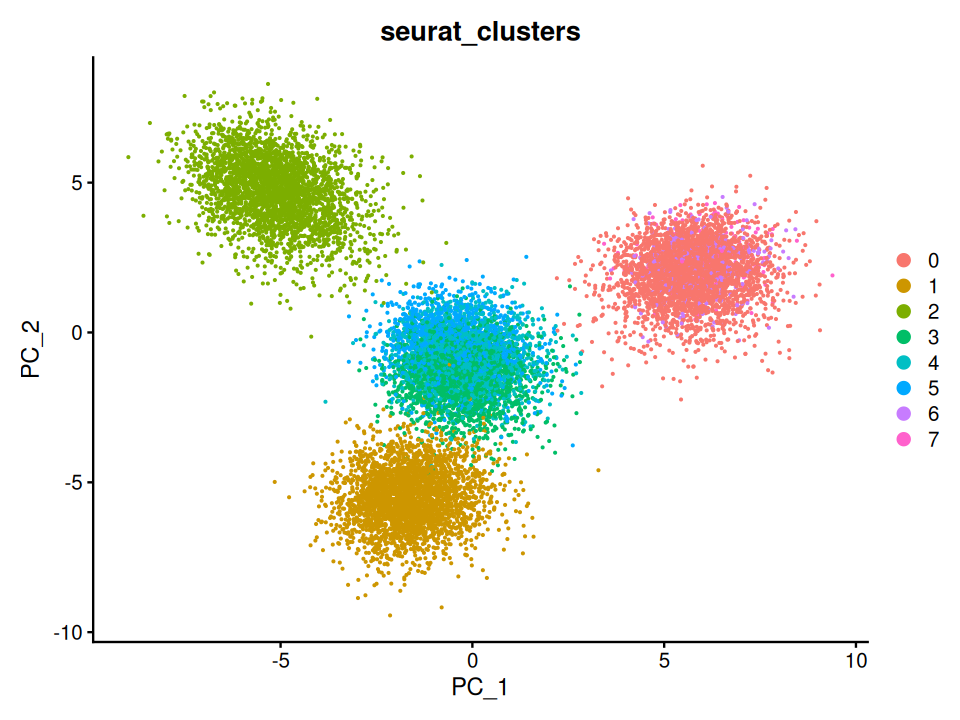

In [70]:
options(repr.plot.width =8, repr.plot.height=6)

DimPlot(splater_sim,reduction = 'pca',group.by = "seurat_clusters", label = FALSE)  

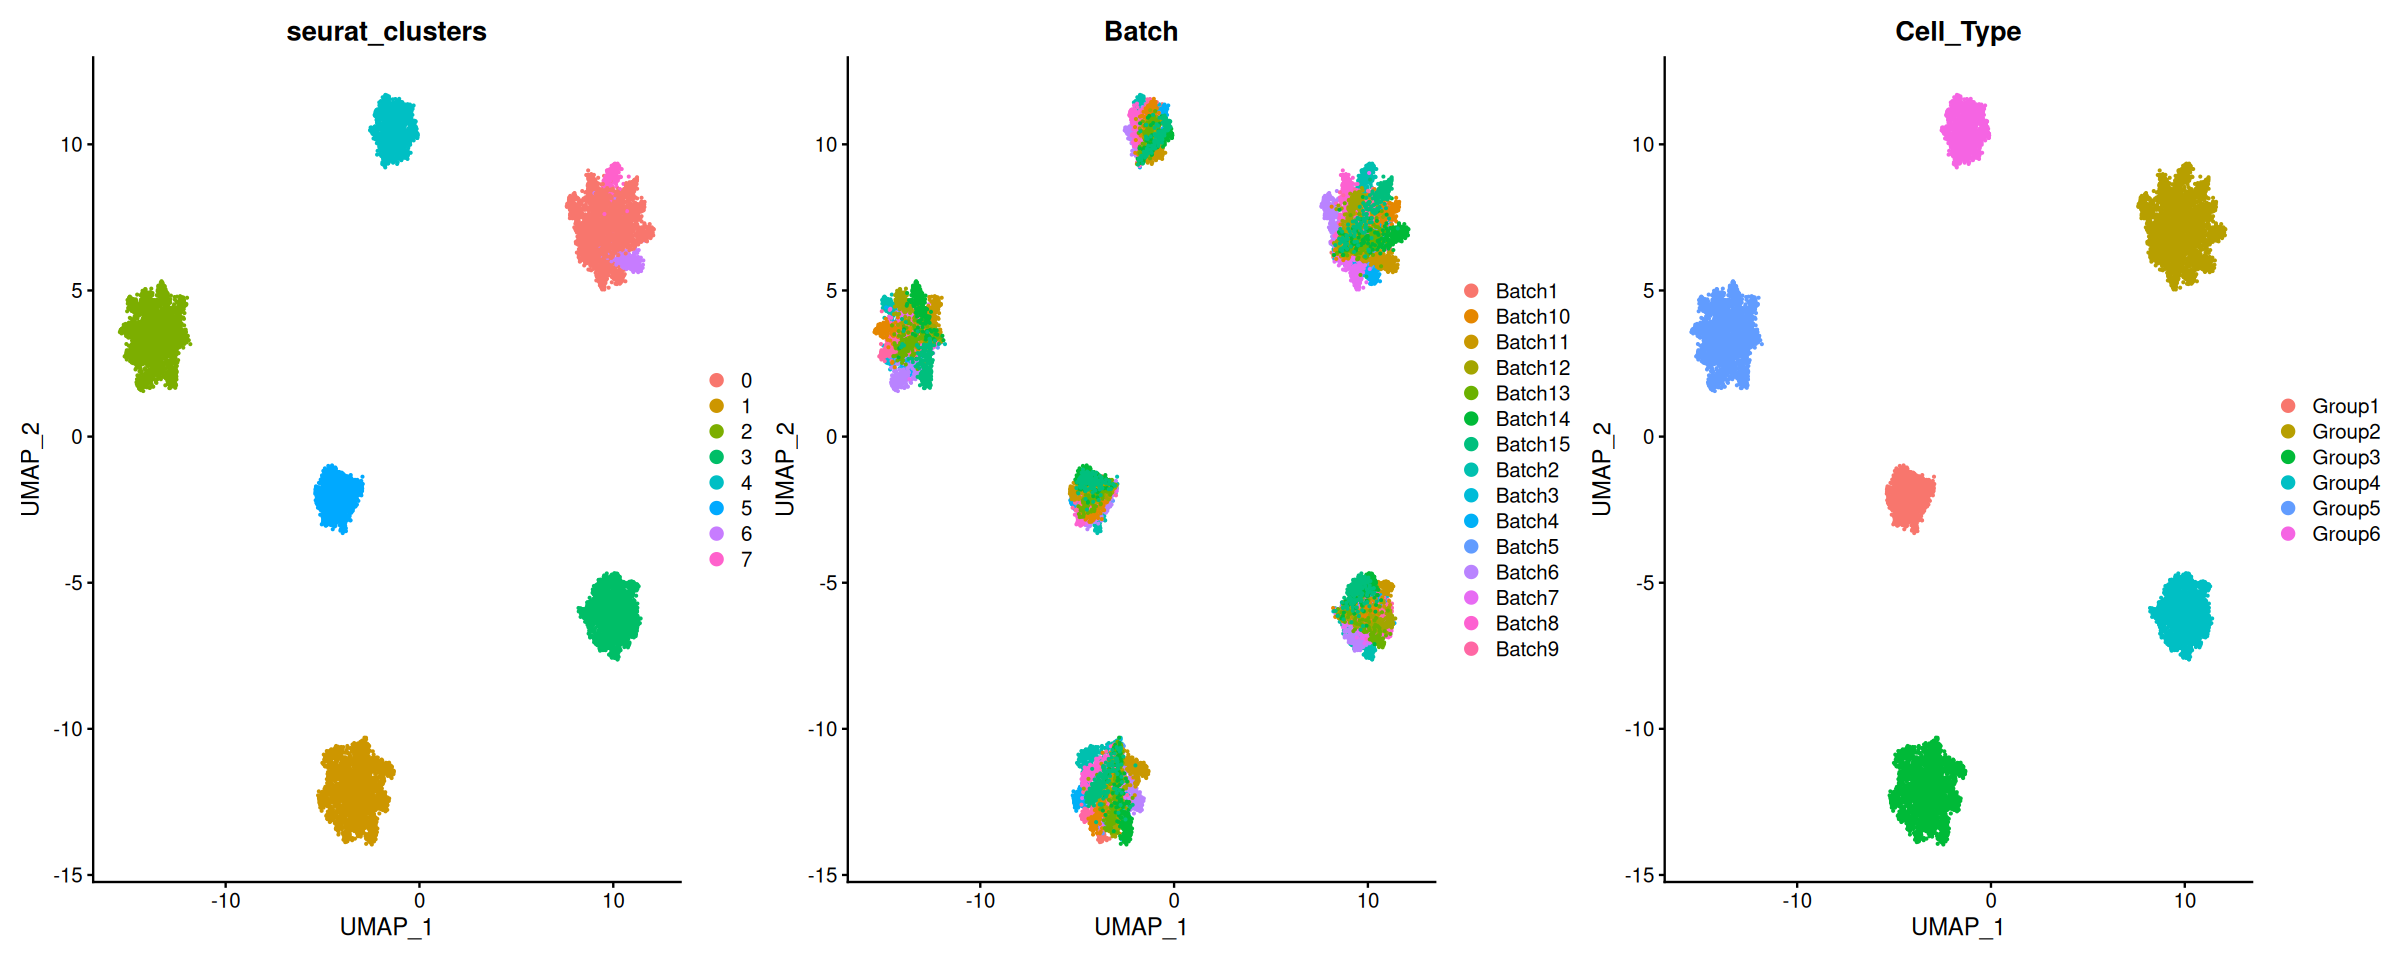

In [76]:
options(repr.plot.width =20, repr.plot.height=8)

DimPlot(splater_sim, group.by = c("seurat_clusters", "Batch","Cell_Type" ), label = FALSE)  # group
# DimPlot(splater_sim, group.by = "Batch", label = FALSE)  # batch
#  DimPlot(sesplater_sim,group.by = "Cell_Type", label = FALSE)                      # cluster

In [77]:
table(splater_sim$Batch)


Idents(splater_sim) <- 'Batch'

split_list <- SplitObject(splater_sim,split.by = 'Batch' )

split_list


 Batch1 Batch10 Batch11 Batch12 Batch13 Batch14 Batch15  Batch2  Batch3  Batch4 
    800    1000    1150     950     850    1250    1225    1200     900    1100 
 Batch5  Batch6  Batch7  Batch8  Batch9 
    700    1300     950    1050     850 

$Batch1
An object of class Seurat 
23867 features across 800 samples within 1 assay 
Active assay: RNA (23867 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, harmony, umap

$Batch2
An object of class Seurat 
23867 features across 1200 samples within 1 assay 
Active assay: RNA (23867 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, harmony, umap

$Batch3
An object of class Seurat 
23867 features across 900 samples within 1 assay 
Active assay: RNA (23867 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, harmony, umap

$Batch4
An object of class Seurat 
23867 features across 1100 samples within 1 assay 
Active assay: RNA (23867 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, harmony, umap

$Batch5
An obj

In [78]:
#Select HVGs form every sample separatly
hvgs_list <- lapply(split_list, function(seurat_obj) {


    seurat_obj <- FindVariableFeatures(seurat_obj, selection.method = "vst", nfeatures = 3000)
  
    
  VariableFeatures(seurat_obj)
})


names(hvgs_list) <- names(split_list)


In [79]:
all_hvgs <- unlist(hvgs_list)

hvg_counts <- table(all_hvgs)

head(hvg_counts)

hvg_freq_df <- data.frame(
  gene = names(hvg_counts),
  frequency = as.integer(hvg_counts)
)

hvg_freq_df <- hvg_freq_df[order(-hvg_freq_df$frequency), ]

all_hvgs
  Gene100 Gene10003 Gene10004 Gene10005 Gene10006 Gene10007 
       13        13         1         7         5         4 

In [80]:
length(all_hvgs)

head(hvg_freq_df,15)

tail(hvg_freq_df)

[1] 45000

,gene,frequency
,<chr>,<int>
8,Gene1001,15
12,Gene10020,15
24,Gene10041,15
30,Gene10056,15
42,Gene10085,15
49,Gene10096,15
58,Gene10117,15
60,Gene10122,15
75,Gene10188,15


,gene,frequency
,<chr>,<int>
8509,Gene9947,1
8513,Gene9962,1
8514,Gene997,1
8516,Gene9977,1
8520,Gene9980,1
8521,Gene9981,1


In [81]:
HVGs <- head(hvg_freq_df$gene,3000)
head(HVGs,30)

[1] "Gene1001"  "Gene10020" "Gene10041" "Gene10056" "Gene10085" "Gene10096"
 [7] "Gene10117" "Gene10122" "Gene10188" "Gene10194" "Gene10270" "Gene10404"
[13] "Gene10446" "Gene10490" "Gene10535" "Gene1054"  "Gene10541" "Gene10551"
[19] "Gene10567" "Gene10647" "Gene10711" "Gene10799" "Gene10804" "Gene10819"
[25] "Gene10820" "Gene10825" "Gene10853" "Gene10950" "Gene10970" "Gene10982"

In [82]:
dir <- "/mnt/fast00/Minghui/Simulate_data/"

for (i in names(split_list)) {

     sample_dir <- file.path(dir, i)
  if (!dir.exists(sample_dir)) dir.create(sample_dir, recursive = TRUE)

  # 提取并归一化
  obj <- ScaleData(split_list[[i]], features = HVGs, do.center = FALSE, verbose = FALSE)
  data <- GetAssayData(obj, slot = "scale.data") %>% as.matrix()
  
  # 负数归零
  data[data < 0] <- 0
  
  # 修复方差为 0 的行
  zero_var_rows <- which(apply(data, 1, var) == 0)
  for (j in zero_var_rows) {
    col_index <- sample(ncol(data), 1)
    data[j, col_index] <- 1e-10
  }

  # 保存为 txt 文件到对应子目录
  out_file <- file.path(sample_dir, "scaled_matrix.txt")
  write.table(data, file = out_file, sep = "\t", quote = FALSE, row.names = FALSE,col.names = FALSE)

  message("Scaled matrix saved: ", out_file)
}


Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data//Batch1/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data//Batch2/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data//Batch3/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data//Batch4/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data//Batch5/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data//Batch6/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data//Batch7/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data//Batch8/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data//Batch9/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data//Batch10/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data//Batch11/scaled_matrix.txt

Scaled matrix saved: /mnt/fast00/Minghui/Simulate_data//Batch12/scaled_matrix.txt

Scaled matrix

In [83]:
# bash:
# (torchnmf) minghui@kno03:/mnt/fast00/Minghui/Simulate_data$ python nsnmf.py
# Using device: cuda


In [84]:
w_dir <- "/mnt/fast00/Minghui/Simulate_data/output_csv"


target_files <- sapply(names(split_list), function(sample_name) {
#   k_value <- sample_k_list[[sample_name]]
  file.path(w_dir, paste0(sample_name, "_k", 10, "_theta03_W.csv"))
}, USE.NAMES = TRUE)

print(target_files)


                                                                  Batch1 
 "/mnt/fast00/Minghui/Simulate_data/output_csv/Batch1_k10_theta03_W.csv" 
                                                                  Batch2 
 "/mnt/fast00/Minghui/Simulate_data/output_csv/Batch2_k10_theta03_W.csv" 
                                                                  Batch3 
 "/mnt/fast00/Minghui/Simulate_data/output_csv/Batch3_k10_theta03_W.csv" 
                                                                  Batch4 
 "/mnt/fast00/Minghui/Simulate_data/output_csv/Batch4_k10_theta03_W.csv" 
                                                                  Batch5 
 "/mnt/fast00/Minghui/Simulate_data/output_csv/Batch5_k10_theta03_W.csv" 
                                                                  Batch6 
 "/mnt/fast00/Minghui/Simulate_data/output_csv/Batch6_k10_theta03_W.csv" 
                                                                  Batch7 
 "/mnt/fast00/Minghui/Simulate_data/ou

In [85]:
w_list <- lapply(target_files, function(f) {
  as.matrix(read.csv(f, header = FALSE))
})


names(w_list) <- names(target_files)


print(names(w_list))


 [1] "Batch1"  "Batch2"  "Batch3"  "Batch4"  "Batch5"  "Batch6"  "Batch7" 
 [8] "Batch8"  "Batch9"  "Batch10" "Batch11" "Batch12" "Batch13" "Batch14"
[15] "Batch15"


In [86]:
w_list <- w_list[!(names(w_list) %in% "Group9")]
gene_names <- HVGs

w_list <- lapply(names(w_list), function(sample_name) {
  mat <- w_list[[sample_name]]
  
  rownames(mat) <- gene_names
  colnames(mat) <- paste0(sample_name, "_Program_", seq_len(ncol(mat)))
  
  return(mat)
})

# 把名字重新加回去
names(w_list) <- names(w_list)

In [87]:

head(w_list[[1]])

,Batch1_Program_1,Batch1_Program_2,Batch1_Program_3,Batch1_Program_4,Batch1_Program_5,Batch1_Program_6,Batch1_Program_7,Batch1_Program_8,Batch1_Program_9,Batch1_Program_10
Gene1001,1.391443e-01,0.24815175,0.135002568,0.12955019,0.185382560,0.23901205,0.13521087,0.093244366,0.11474644,0.075439617
Gene10020,2.128275e-05,0.19729960,0.039468266,0.17292762,0.154143602,0.11244677,0.15688448,0.143277198,0.07725041,0.255286664
Gene10041,1.000000e-08,0.02038576,0.010034527,0.18320313,0.026770111,0.00000001,0.02320407,0.003484355,0.19990477,0.015431020
Gene10056,4.999242e-02,0.09065316,0.105032653,0.05444439,0.128047660,0.18231003,0.15885673,0.057049673,0.05800225,0.000000010
Gene10085,1.000000e-08,0.00000001,0.002753318,0.00000001,0.000000010,0.38589871,0.00901199,0.112894095,0.00000001,0.000000010
Gene10096,2.174007e-02,0.05915376,0.067332134,0.67087835,0.001008685,0.17763139,0.10462626,0.035380553,0.07319963,0.001074909


In [88]:
merge_matrix <- do.call(cbind ,w_list)
mat_unit <- apply(merge_matrix, 2, function(x) x / sqrt(sum(x^2))) #L2 normalize the columns
                

,Batch1_Program_1,Batch1_Program_2,Batch1_Program_3,Batch1_Program_4,Batch1_Program_5,Batch1_Program_6,Batch1_Program_7,Batch1_Program_8,Batch1_Program_9,Batch1_Program_10,⋯,Batch15_Program_1,Batch15_Program_2,Batch15_Program_3,Batch15_Program_4,Batch15_Program_5,Batch15_Program_6,Batch15_Program_7,Batch15_Program_8,Batch15_Program_9,Batch15_Program_10
Gene1001,2.328171e-02,3.646592e-02,0.0246855270,1.943632e-02,2.994358e-02,3.892032e-02,0.020179506,0.0153447245,1.992371e-02,1.345805e-02,⋯,0.0216073219,3.796861e-02,0.023543734,1.824936e-02,1.966687e-02,7.035447e-03,0.028644520,2.286934e-02,0.031195665,1.844136e-02
Gene10020,3.561042e-06,2.899319e-02,0.0072168623,2.594420e-02,2.489777e-02,1.831064e-02,0.023414177,0.0235783589,1.341318e-02,4.554188e-02,⋯,0.0177806614,1.964706e-02,0.018622003,3.152903e-02,2.631152e-02,1.919292e-02,0.009363378,2.244522e-02,0.027173444,1.564633e-02
Gene10041,1.673206e-09,2.995689e-03,0.0018348360,2.748583e-02,4.323994e-03,1.628383e-09,0.003463084,0.0005734016,3.470996e-02,2.752818e-03,⋯,0.0104612233,2.609533e-03,0.001436717,4.902824e-03,1.698134e-09,1.813908e-09,0.051963566,1.541659e-09,0.017964879,2.075186e-02
Gene10056,8.364760e-03,1.332149e-02,0.0192054596,8.168250e-03,2.068267e-02,2.968706e-02,0.023708526,0.0093883582,1.007107e-02,1.783950e-09,⋯,0.0237211741,1.196249e-02,0.010880752,1.744144e-09,2.023912e-06,1.141788e-02,0.059721936,3.511999e-03,0.014252896,2.448705e-02
Gene10085,1.673206e-09,1.469501e-09,0.0005034505,1.500292e-09,1.615232e-09,6.283910e-02,0.001344992,0.0185783749,1.736325e-09,1.783950e-09,⋯,0.0009623867,2.082857e-06,0.005477623,3.530784e-02,2.287496e-09,2.014245e-02,0.020651782,1.285491e-06,0.000817462,1.553001e-09
Gene10096,3.637561e-03,8.692649e-03,0.0123118339,1.006514e-01,1.629260e-04,2.892520e-02,0.015614915,0.0058223876,1.270983e-02,1.917585e-04,⋯,0.0081769507,1.303544e-02,0.018459663,1.230870e-02,1.993862e-02,9.332113e-03,0.017936160,1.739674e-02,0.092676718,6.583530e-05


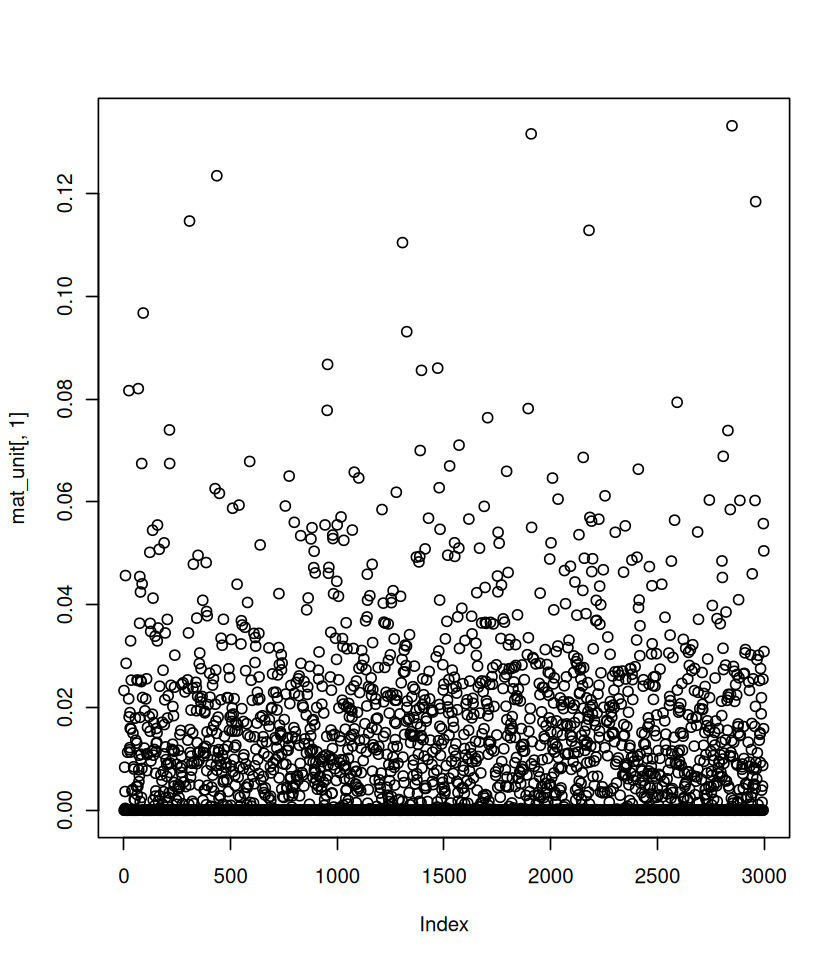

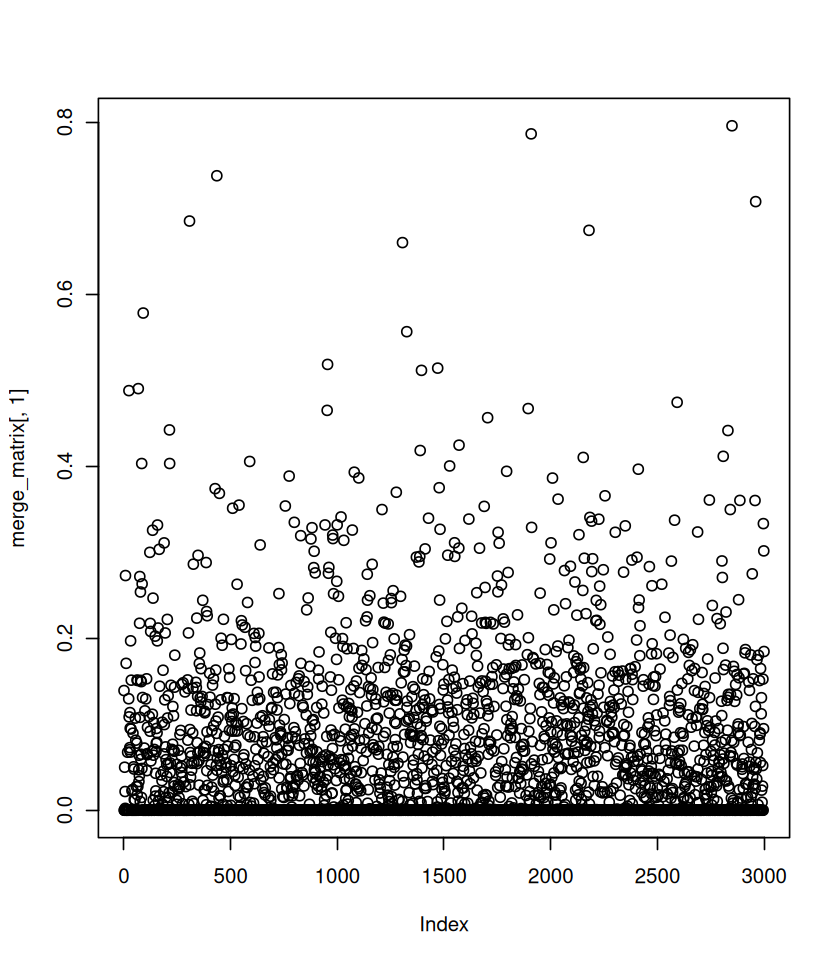

In [90]:
options(repr.plot.width =7, repr.plot.height=8)

head(mat_unit)

plot(mat_unit[,1])

plot(merge_matrix[,1])


In [91]:
pam_data <- pam(t(mat_unit),20 )

names(pam_data)

[1] "medoids"    "id.med"     "clustering" "objective"  "isolation" 
 [6] "clusinfo"   "silinfo"    "diss"       "call"       "data"

[1] 0.5625535 0.5642502 0.5708264 0.5697322 0.6243610 0.5630943

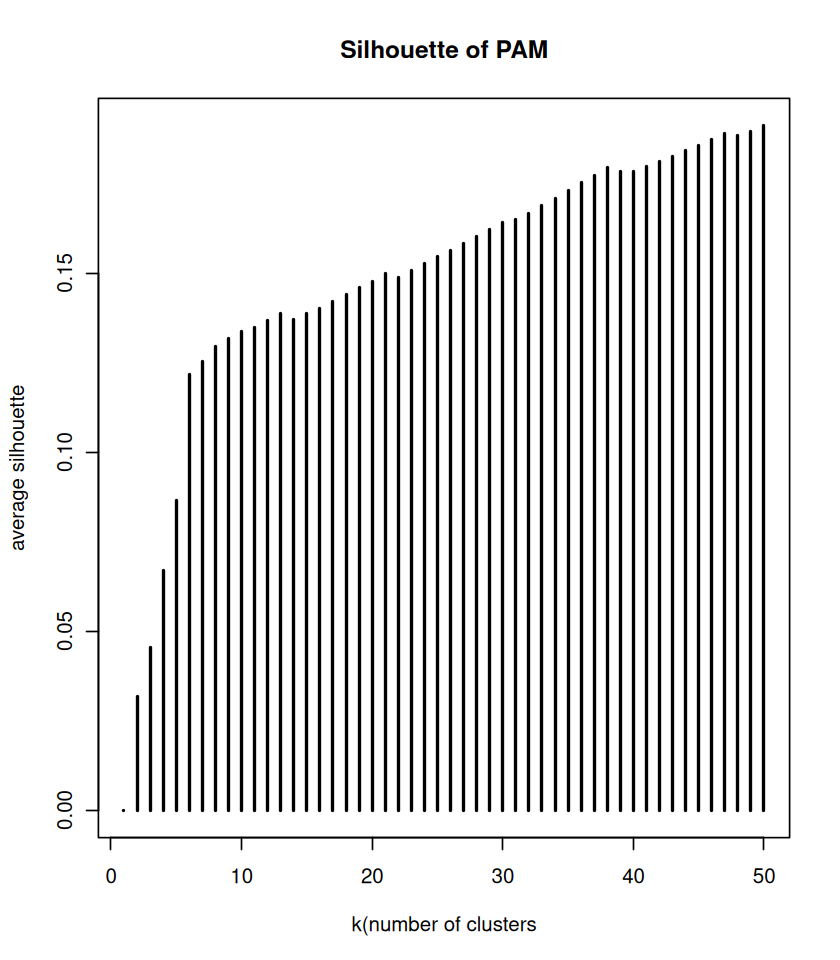

In [109]:
library(vegan)

otu_dist=vegdist(t(mat_unit), method="bray", diag=TRUE, upper=TRUE, p=2)

head(otu_dist)

library(fpc)
library(cluster)
pambest=pamk(otu_dist)
k=pambest$nc

asw <- numeric(50)
for (i in 2:50) {
  asw[i]=pam(otu_dist, i)$silinfo$avg.width
}
k.best=which.max(asw)
plot(1:length(asw), asw, type="h", main="Silhouette of PAM", lwd=2,
     xlab="k(number of clusters", ylab="average silhouette")

In [110]:
k = 30

pam_data <- pam(t(mat_unit),k )
medoid_names <- pam_data$medoids

# 从原矩阵中提取这些列（对应 medoid）
medoid_vectors <- mat_unit[, rownames( pam_data$medoids)]

# 批量读取W矩阵
w_list <- lapply(target_files, function(f) {
  as.matrix(read.csv(f, header = FALSE))
})

# 设置名字为样本名
names(w_list) <- names(target_files)

# 检查
print(names(w_list))


 [1] "Batch1"  "Batch2"  "Batch3"  "Batch4"  "Batch5"  "Batch6"  "Batch7" 
 [8] "Batch8"  "Batch9"  "Batch10" "Batch11" "Batch12" "Batch13" "Batch14"
[15] "Batch15"


In [111]:
head(medoid_vectors)

,Batch1_Program_1,Batch2_Program_1,Batch14_Program_3,Batch15_Program_9,Batch15_Program_10,Batch15_Program_1,Batch14_Program_6,Batch1_Program_10,Batch2_Program_3,Batch2_Program_10,⋯,Batch11_Program_2,Batch11_Program_6,Batch12_Program_6,Batch13_Program_3,Batch13_Program_4,Batch14_Program_4,Batch14_Program_5,Batch14_Program_7,Batch15_Program_4,Batch15_Program_6
Gene1001,2.328171e-02,4.369345e-02,2.135324e-02,0.031195665,1.844136e-02,0.0216073219,0.022142028,1.345805e-02,9.163932e-04,2.887460e-02,⋯,2.054894e-04,1.872402e-02,4.768801e-04,2.351667e-02,0.036179122,1.100792e-02,1.306342e-02,2.746494e-02,1.824936e-02,7.035447e-03
Gene10020,3.561042e-06,2.225486e-02,7.973534e-03,0.027173444,1.564633e-02,0.0177806614,0.020198950,4.554188e-02,2.350978e-02,6.664169e-03,⋯,1.029945e-03,2.479587e-02,1.228157e-02,1.839006e-03,0.024651710,3.334749e-02,1.449447e-02,3.139289e-02,3.152903e-02,1.919292e-02
Gene10041,1.673206e-09,1.213870e-02,1.726580e-09,0.017964879,2.075186e-02,0.0104612233,0.014090767,2.752818e-03,9.592049e-03,1.814803e-09,⋯,7.846323e-03,1.725870e-09,1.654644e-09,2.240905e-02,0.008227598,7.451009e-03,3.655169e-02,1.165389e-02,4.902824e-03,1.813908e-09
Gene10056,8.364760e-03,1.605293e-02,1.807350e-02,0.014252896,2.448705e-02,0.0237211741,0.021362099,1.783950e-09,1.023272e-04,1.696225e-02,⋯,1.261369e-05,8.149030e-05,1.654644e-09,1.467800e-09,0.017123093,1.750636e-09,1.642914e-09,1.832311e-06,1.744144e-09,1.141788e-02
Gene10085,1.673206e-09,1.434333e-09,2.802050e-02,0.000817462,1.553001e-09,0.0009623867,0.001819166,1.783950e-09,1.671096e-09,3.194747e-09,⋯,8.850879e-03,9.238762e-04,1.654644e-09,1.467800e-09,0.011225141,1.750636e-09,1.642914e-09,1.982941e-09,3.530784e-02,2.014245e-02
Gene10096,3.637561e-03,8.382485e-03,9.867639e-03,0.092676718,6.583530e-05,0.0081769507,0.008419206,1.917585e-04,4.435890e-02,9.350946e-03,⋯,1.515764e-02,3.465374e-03,9.019029e-03,1.467800e-09,0.017667905,1.959391e-02,2.583712e-02,9.720623e-05,1.230870e-02,9.332113e-03


In [112]:
# seurat_sim_data <- subset(seu,group %in% names(w_list))
splater_sim  <- ScaleData(object = splater_sim,do.center = F,features =rownames(merge_matrix) )  
norm_expression <- splater_sim@assays$RNA@scale.data


Scaling data matrix



In [113]:
compute_usage_matrix_parallel <- function(norm_expression, norm_components, n_cores = NULL) {
  
  library(nnls)
  library(doParallel)
  library(foreach)
  

  n_cells <- ncol(norm_expression)
  n_components <- ncol(norm_components)
  usage_matrix <- matrix(0, nrow = n_cells, ncol = n_components)
  rownames(usage_matrix) <- colnames(norm_expression)
  colnames(usage_matrix) <- colnames(norm_components)
  
  cl <- makeCluster(n_cores)
  registerDoParallel(cl)
  
  clusterExport(cl, c("norm_components"), envir = environment())
  
  # NNLS
  usage_list <- foreach(i = 1:n_cells, .packages = "nnls") %dopar% {
    fit <- nnls::nnls(norm_components, norm_expression[, i])
    fit$x
  }
  
  stopCluster(cl)
  
  usage_matrix <- do.call(rbind, usage_list)
  rownames(usage_matrix) <- colnames(norm_expression)
  colnames(usage_matrix) <- colnames(norm_components)
  
  return(usage_matrix)
}

In [114]:
# Parallel 
chunk_size <- 1000  # cell number in every chunks
chunks <- split(1:ncol(norm_expression), ceiling(seq_along(1:ncol(norm_expression))/chunk_size))

results <- lapply(chunks, function(idx) {
  compute_usage_matrix_parallel(norm_expression[, idx],n_cores = 25, medoid_vectors)
})

usage_matrix <- do.call(rbind, results)

In [116]:
splater_sim[['Consensus']] <- CreateDimReducObject(
  embeddings = as.matrix(usage_matrix),  # Ensure this is a numeric matrix
  key = 'Consensus_',  # Set the key for the reduction
  assay = 'RNA'  # Specify the assay if necessary
)

In [117]:
n =15

splater_sim_res <- FindNeighbors(splater_sim, dims = 1:n, reduction = 'Consensus')
splater_sim_res <- RunUMAP(splater_sim_res, reduction = 'Consensus', dims = 1:n)

splater_sim_res <- FindClusters(splater_sim_res,resolution = 1.5 )

# resolution = 1 32 clusters

# resolution = 1.5 41 clusters
# resolution = 2 46 clusters

Computing nearest neighbor graph

Computing SNN

14:21:16 UMAP embedding parameters a = 0.9922 b = 1.112

14:21:16 Read 15275 rows and found 15 numeric columns

14:21:16 Using Annoy for neighbor search, n_neighbors = 30

14:21:16 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

14:21:17 Writing NN index file to temp file /tmp/RtmpwmiIV7/file1352916e692da

14:21:17 Searching Annoy index using 1 thread, search_k = 3000

14:21:22 Annoy recall = 99.97%

14:21:23 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

14:21:23 4 smooth knn distance failures

14:21:25 Initializing from normalized Laplacian + noise (using irlba)

14:21:25 Commencing optimization for 200 epochs, with 677472 positive edges

14:21:25 Using rng type: pcg

14:21:31 

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 15275
Number of edges: 440330

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.7519
Number of communities: 10
Elapsed time: 1 seconds


In [175]:
# # 模拟参数

# set.seed(123)
# G <- 3000  # 基因数
# C <- 2000  # 细胞数
# K <- 10    # GEP 数

# # 构建 W_true（G × K）
# W_true <- matrix(0, G, K)
# for (k in 1:K) {
#   genes_active <- sample(1:G, 100)
#   W_true[genes_active, k] <- runif(100, 5, 10)
# }

# # 构建 H_true（K × C）
# H_true <- matrix(0, K, C)
# for (c in 1:C) {
#   id_program <- sample(1:7, 1)
#   H_true[id_program, c] <- runif(1, 0.6, 1)
#   if (runif(1) < 0.1) {
#     act_program <- sample(8:10, 1)
#     H_true[act_program, c] <- runif(1, 0.2, 0.5)
#   }
# }

# # 原始非负表达矩阵
# X <- W_true %*% H_true

# # 添加高斯噪声并截断负值
# X <- X + matrix(rnorm(G * C, mean=0, sd=0.5), G, C)
# X[X < 0] <- 0

# # 添加平滑背景矩阵（模拟 housekeeping 基因或全局趋势）
# S <- matrix(runif(G * C, min=0, max=0.1), G, C)
# X <- X + S


In [118]:
cluster_cols <- c(
  "#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72",
  "#B17BA6", "#FF7F00", "#FDB462", "#E7298A", "#E78AC3",
  "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D",
  "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999",
  "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000",
  "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00")

In [119]:
colnames(splater_sim@meta.data)

[1] "orig.ident"      "nCount_RNA"      "nFeature_RNA"    "Batch"          
[5] "Cell_Type"       "RNA_snn_res.0.5" "seurat_clusters"

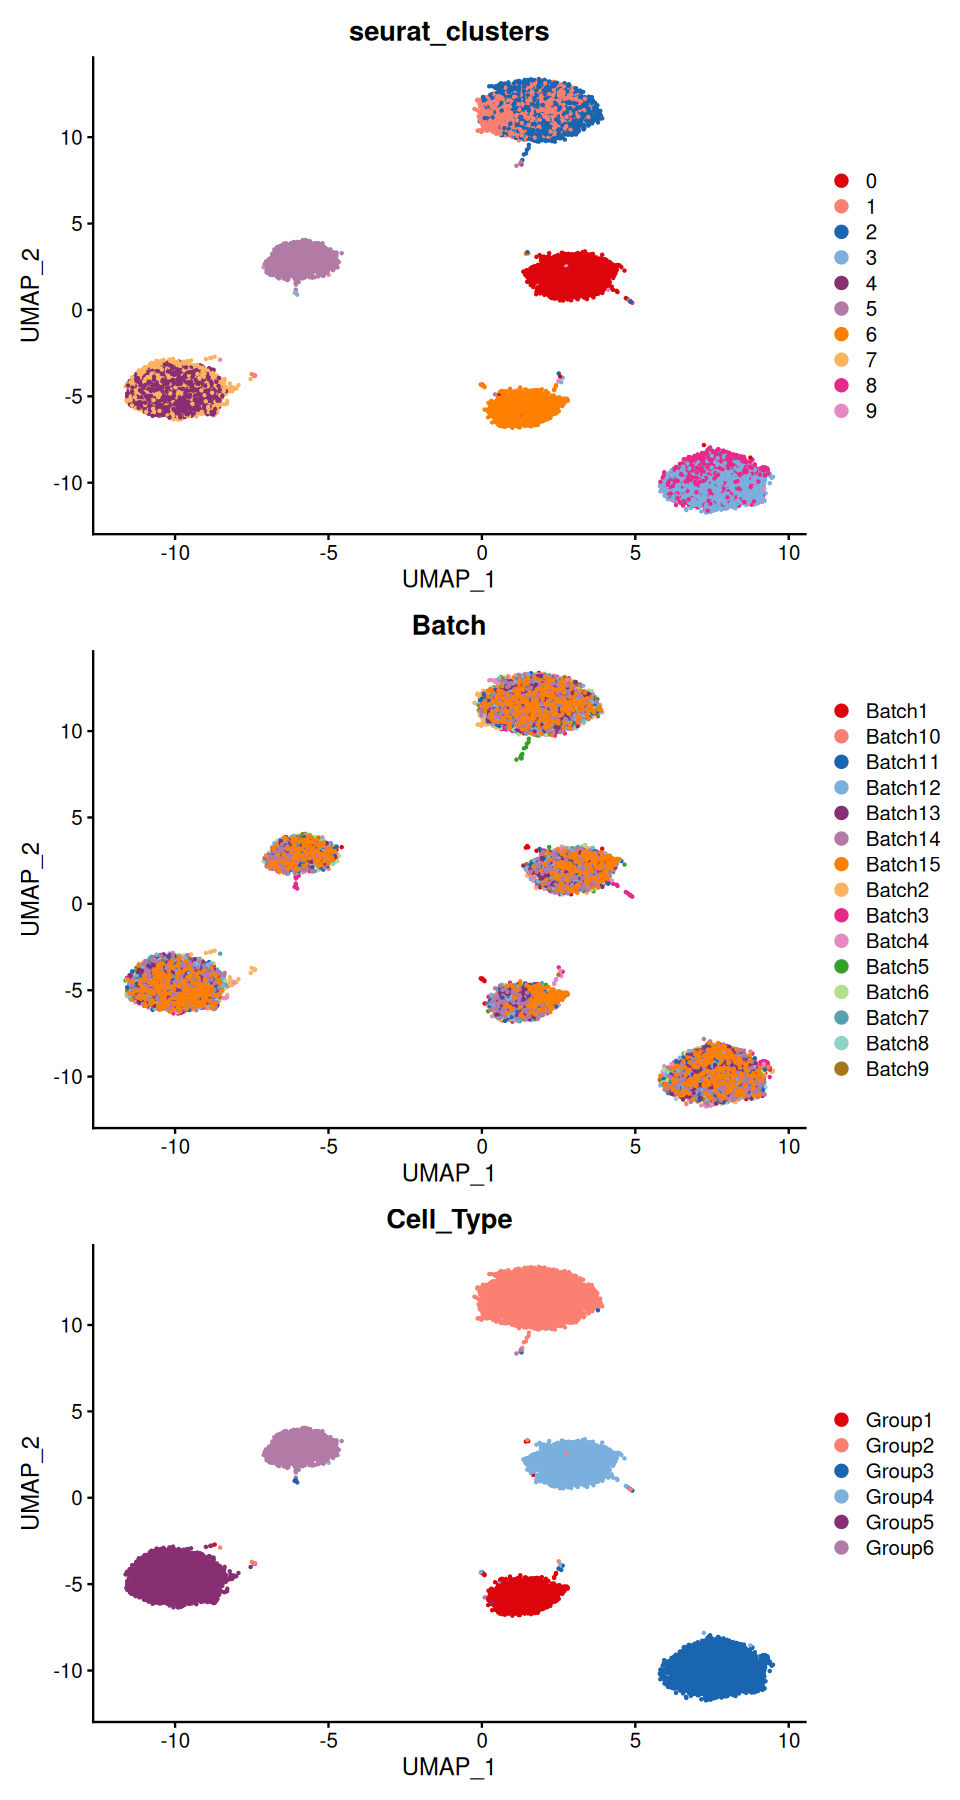

In [120]:
options(repr.plot.width =8, repr.plot.height=15)

DimPlot(splater_sim_res,reduction = "umap",group.by = c('seurat_clusters', 'Batch','Cell_Type'),label = F,raster=FALSE,pt.size = 0.2,ncol = 1,cols =  rep(cluster_cols,3))
